# 📊 Analisis & Prediksi Nilai Rupiah (USD/IDR)
**Dataset:** Daily Multi-Asset Macroeconomic & Financial Time Series — Indonesia & Global Markets  
**Periode:** Januari 2010 – Mei 2026  
**Variabel:** OIL, GOLD, USD/IDR, S&P500, IHSG, VIX, CPI, BI Rate, US Fed Rate

---
Notebook ini dibagi menjadi tiga bagian utama:
1. **Eksplorasi Data** — melihat tren, distribusi, dan kualitas data
2. **Analisis Multi-Aset** — hubungan antar variabel dengan Rupiah
3. **Prediksi USDIDR** — model prediksi berbasis regresi + visualisasi hasil

## ⚙️ Setup: Import Library & Load Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Styling grafik
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print('Library berhasil di-import')

Library berhasil di-import


In [21]:
# Load dataset
df = pd.read_csv('Macroeconomic and Financial Time Series Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f' Periode data: {df["Date"].min().date()} sampai {df["Date"].max().date()}')
print(f' Jumlah baris x kolom: {df.shape}')
print(f'\n Nama kolom:')
for col in df.columns:
    print(f'  - {col}: {df[col].dtype}')

 Periode data: 2010-01-01 sampai 2026-05-29
 Jumlah baris x kolom: (4277, 10)

 Nama kolom:
  - Date: datetime64[ns]
  - OIL: float64
  - GOLD: float64
  - USDIDR: float64
  - SP500: float64
  - IHSG: float64
  - VIX: float64
  - CPI: float64
  - BI_rate: float64
  - US_rate: float64


---
## 🧹 Bagian 1: Eksplorasi & Pembersihan Data
Sebelum analisis, kita perlu tahu kondisi data (missing values, outlier, dll)

In [22]:
# --- Cek missing values ---
# Data harian sering punya 'gap' di akhir pekan/hari libur
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

summary_missing = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
print('Status Missing Values:')
print(summary_missing)

# Missing values yang ada (hanya 1 baris) kemungkinan besar adalah baris tanggal 1 Jan
# karena pasar global tutup. Kita isi dengan forward-fill.
df = df.ffill()
print('\n Missing values sudah diisi dengan forward-fill (nilai hari sebelumnya)')

Status Missing Values:
         Jumlah Missing  Persentase (%)
Date                  0            0.00
OIL                   1            0.02
GOLD                  1            0.02
USDIDR                0            0.00
SP500                 1            0.02
IHSG                  1            0.02
VIX                   1            0.02
CPI                   0            0.00
BI_rate               0            0.00
US_rate               0            0.00

 Missing values sudah diisi dengan forward-fill (nilai hari sebelumnya)


In [23]:
# --- Statistik Deskriptif ---
# Gambaran umum distribusi tiap variabel
desc = df.describe().T
desc['range'] = desc['max'] - desc['min']
desc = desc[['mean', 'std', 'min', 'max', 'range']].round(2)

# Rename agar lebih mudah dibaca
desc.columns = ['Rata-rata', 'Std Dev', 'Minimum', 'Maksimum', 'Rentang']
desc.index.name = 'Variabel'
print('Statistik Deskriptif:')
print(desc.to_string())

Statistik Deskriptif:
                              Rata-rata      Std Dev              Minimum             Maksimum             Rentang
Variabel                                                                                                          
Date      2018-03-14 06:49:24.507832320          NaN  2010-01-01 00:00:00  2026-05-29 00:00:00  5992 days 00:00:00
OIL                           71.823964    20.797806           -37.630001           123.699997          161.329998
GOLD                        1739.590551   753.225443          1050.800049          5318.399902         4267.599854
USDIDR                     13150.969966  2480.184935           888.109985              17840.0        16951.890015
SP500                       3044.336779  1599.415934          1022.580017          7580.060059         6557.480042
IHSG                        5580.338877  1331.392063          2475.475586          9134.700195         6659.224609
VIX                           18.413835     6.786782      

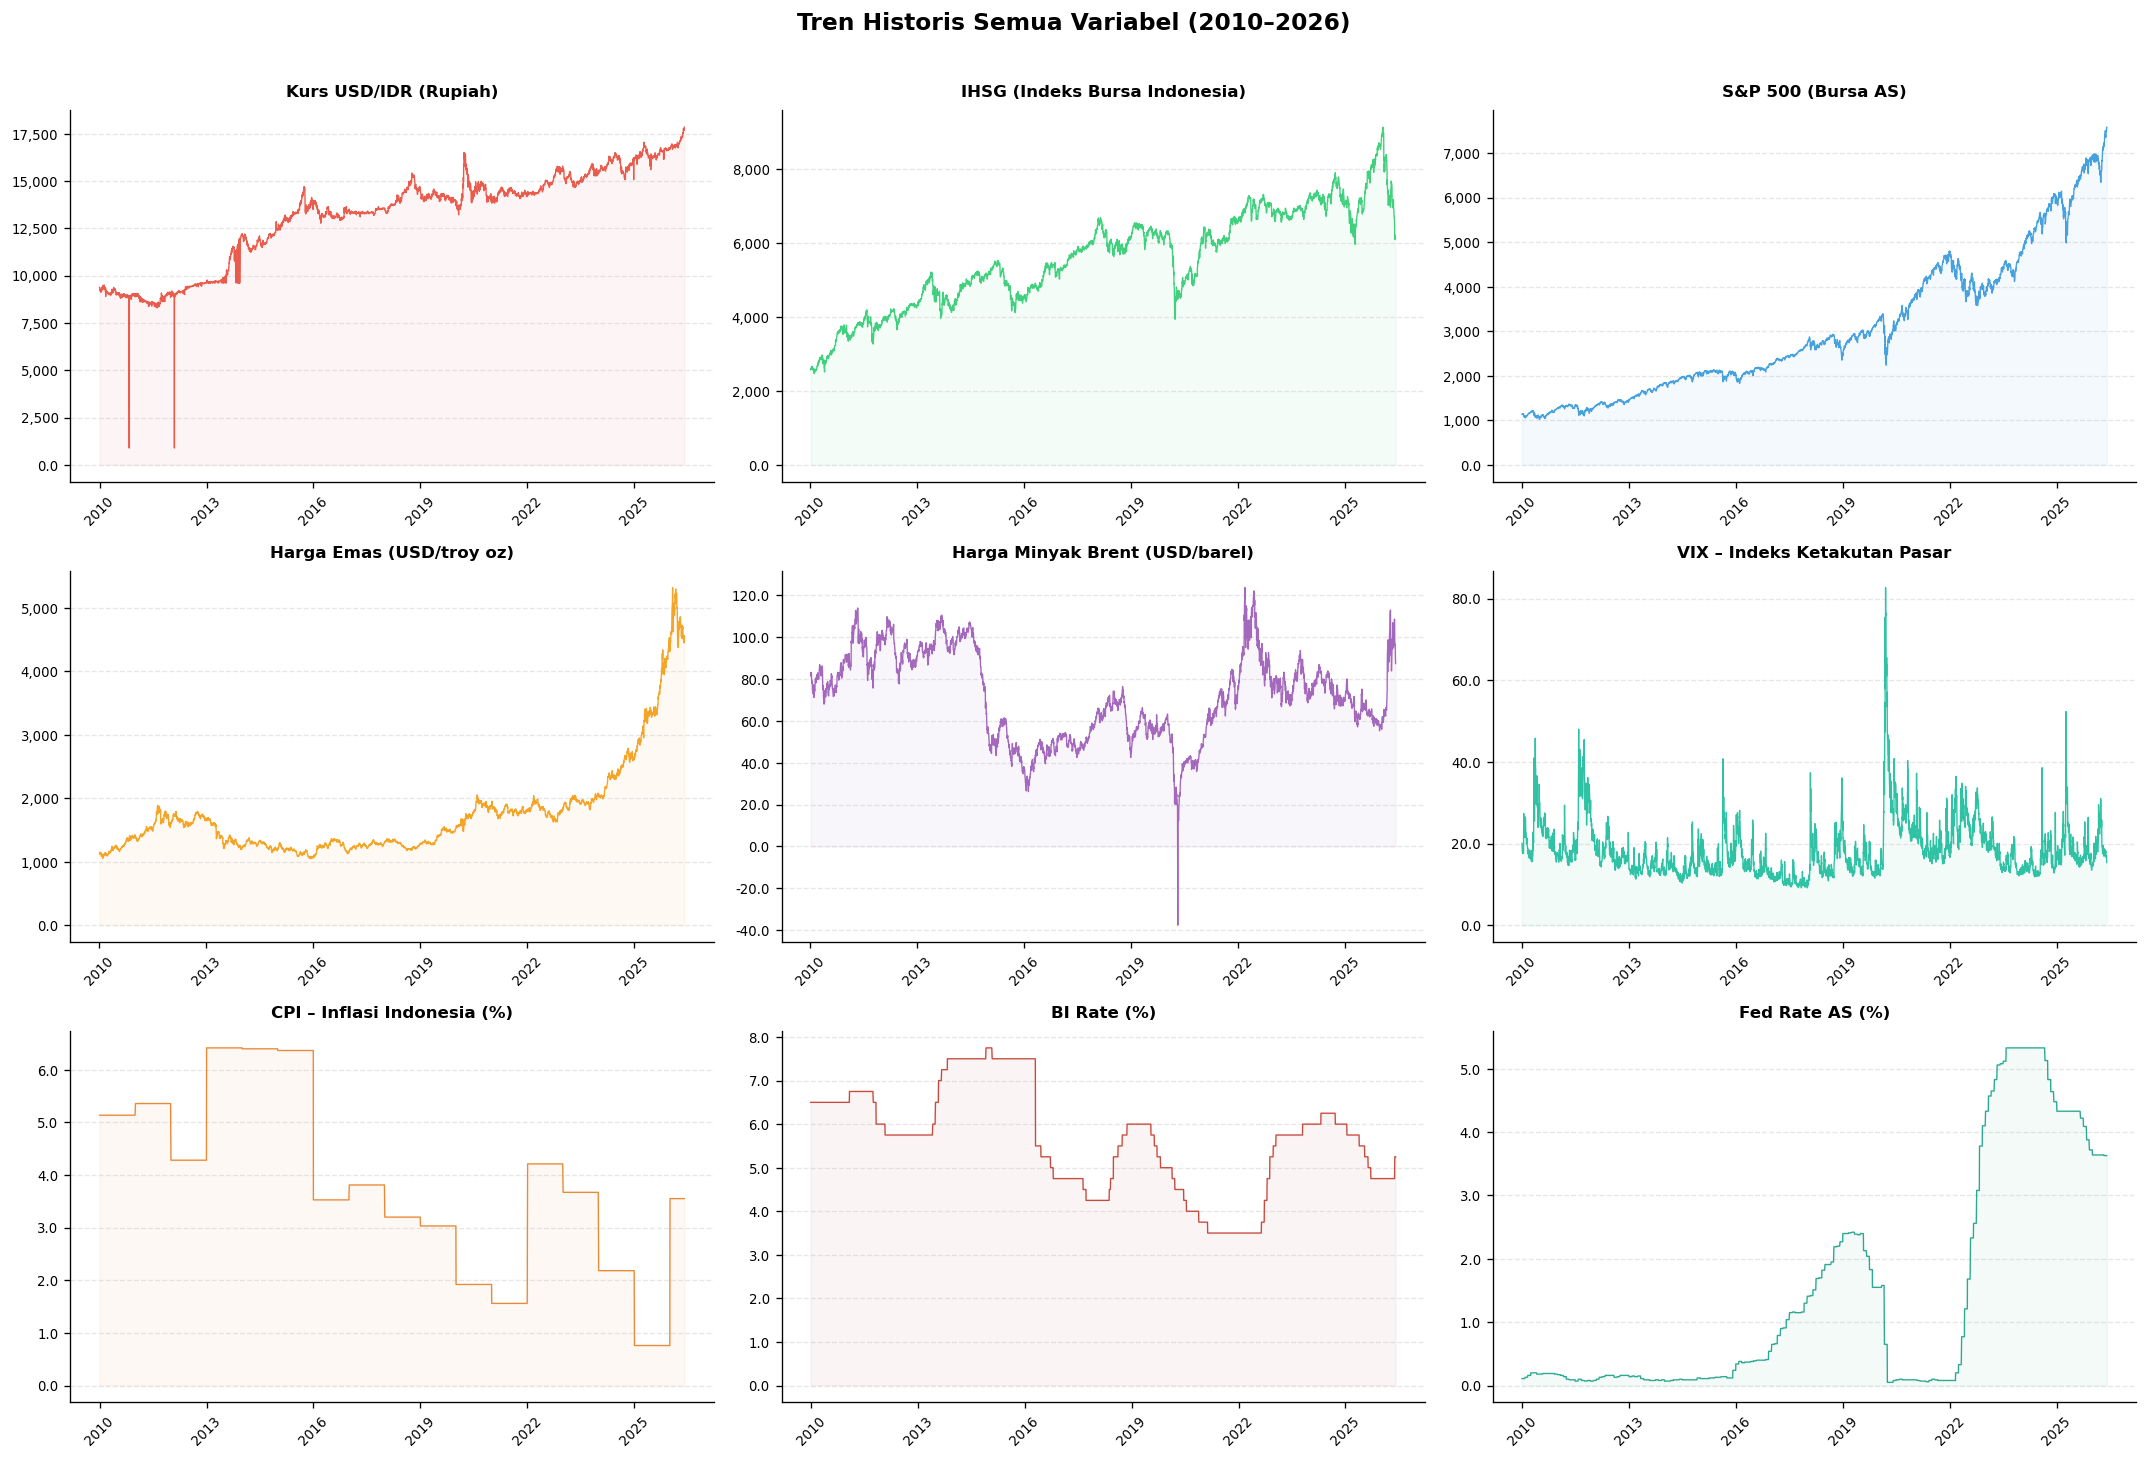

💾 Grafik disimpan: 01_tren_historis.png


In [ ]:
# --- Grafik 1: Tren Historis Semua Variabel ---
# Melihat pergerakan setiap aset dari 2010 sampai sekarang
# Tiap variabel ditampilkan di panel terpisah

cols_to_plot = {
    'USDIDR': 'Kurs USD/IDR (Rupiah)',
    'IHSG': 'IHSG (Indeks Bursa Indonesia)',
    'SP500': 'S&P 500 (Bursa AS)',
    'GOLD': 'Harga Emas (USD/troy oz)',
    'OIL': 'Harga Minyak Brent (USD/barel)',
    'VIX': 'VIX – Indeks Ketakutan Pasar',
    'CPI': 'CPI – Inflasi Indonesia (%)',
    'BI_rate': 'BI Rate (%)',
    'US_rate': 'Fed Rate AS (%)'
}

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#c0392b', '#16a085']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(cols_to_plot.items()):
    ax = axes[i]
    ax.plot(df['Date'], df[col], color=colors[i], linewidth=0.8, alpha=0.9)
    ax.set_title(label, fontsize=10, fontweight='bold', pad=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}' if x >= 1000 else f'{x:.1f}'))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.fill_between(df['Date'], df[col], alpha=0.05, color=colors[i])

plt.suptitle('Tren Historis Semua Variabel (2010–2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_tren_historis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafik disimpan: 01_tren_historis.png')

---
## 🔗 Bagian 2: Analisis Hubungan Antar Variabel
Peranyaan utama: variabel mana yang paling berpengaruh terhadap nilai Rupiah?

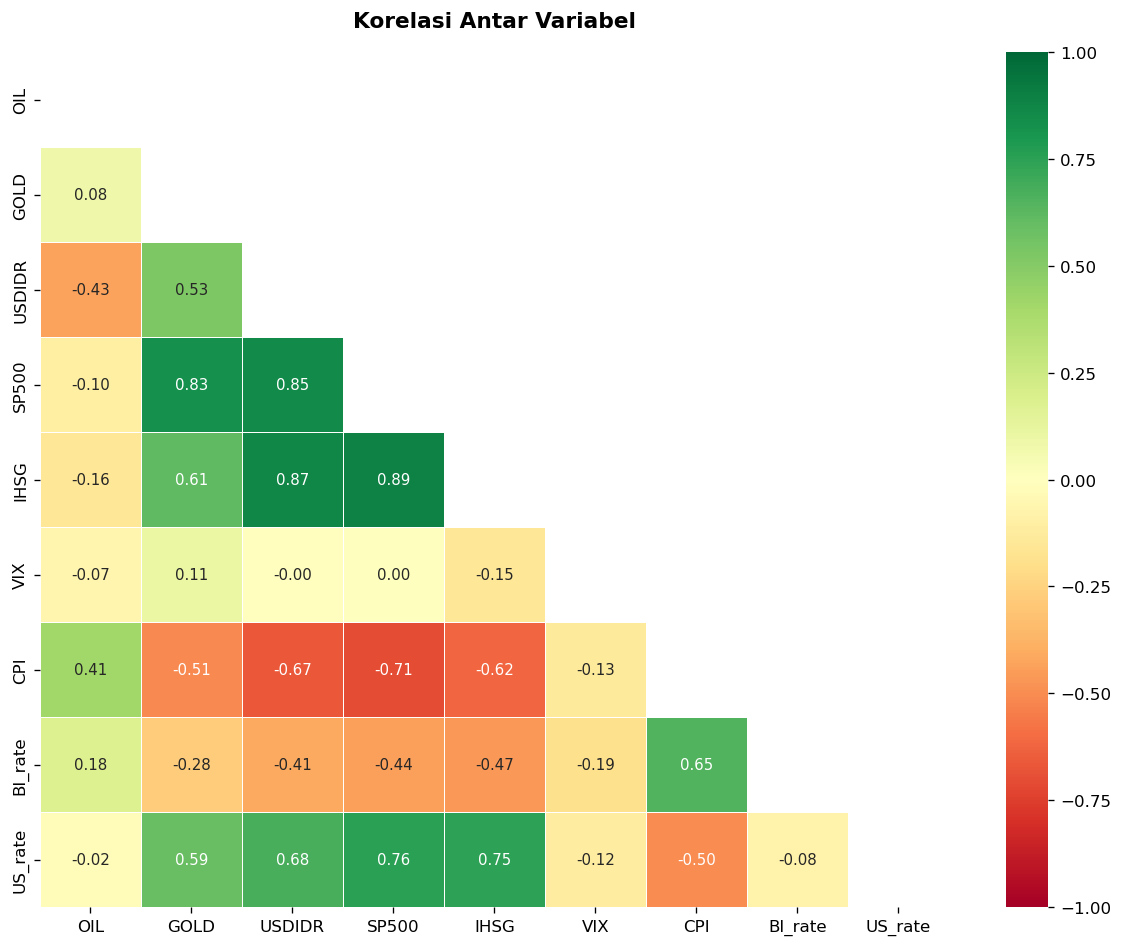

💾 Grafik disimpan: 02_korelasi_heatmap.png


In [ ]:
# --- Heatmap Korelasi ---
# Korelasi mengukur seberapa kuat hubungan dua variabel (skala -1 sampai +1)
# +1 = naik bersama | -1 = bergerak berlawanan | 0 = tidak ada hubungan

num_cols = ['OIL', 'GOLD', 'USDIDR', 'SP500', 'IHSG', 'VIX', 'CPI', 'BI_rate', 'US_rate']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Sembunyikan segitiga atas (duplikat)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax
)

ax.set_title('Korelasi Antar Variabel', 
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('02_korelasi_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafik disimpan: 02_korelasi_heatmap.png')

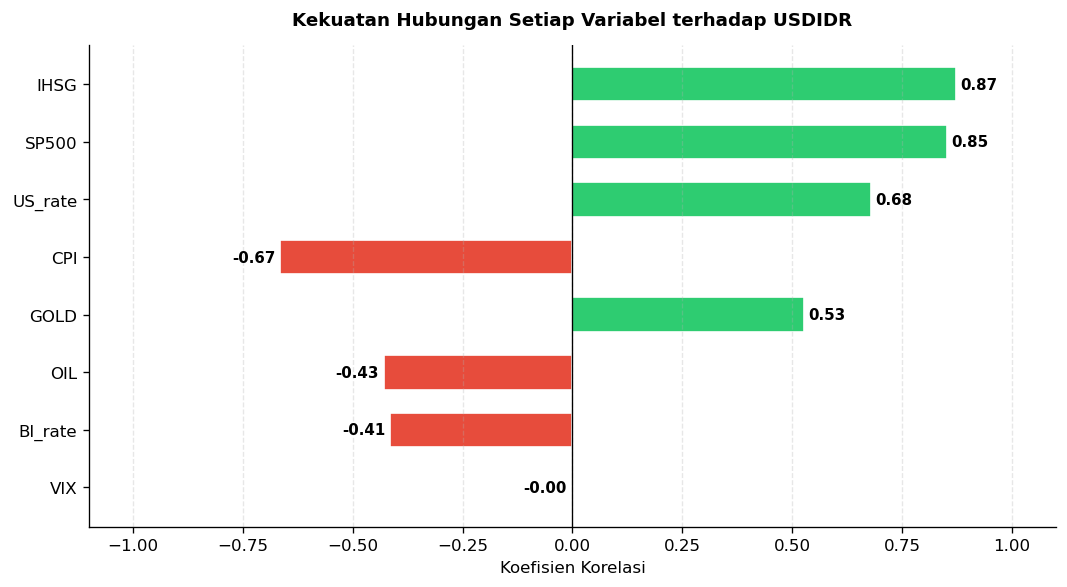

💾 Grafik disimpan: 03_korelasi_usdidr.png


In [25]:
# --- Korelasi Spesifik terhadap USDIDR ---
#  Sort dari yang paling kuat hubungannya (positif maupun negatif)

corr_with_idr = corr_matrix['USDIDR'].drop('USDIDR').sort_values(key=abs, ascending=True)

colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_idr]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(corr_with_idr.index, corr_with_idr.values, color=colors_bar, edgecolor='white', height=0.6)

for bar, val in zip(bars, corr_with_idr.values):
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9, fontweight='bold'
    )

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1.1, 1.1)
ax.set_title('Kekuatan Hubungan Setiap Variabel terhadap USDIDR',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Koefisien Korelasi', fontsize=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('03_korelasi_usdidr.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Grafik disimpan: 03_korelasi_usdidr.png')

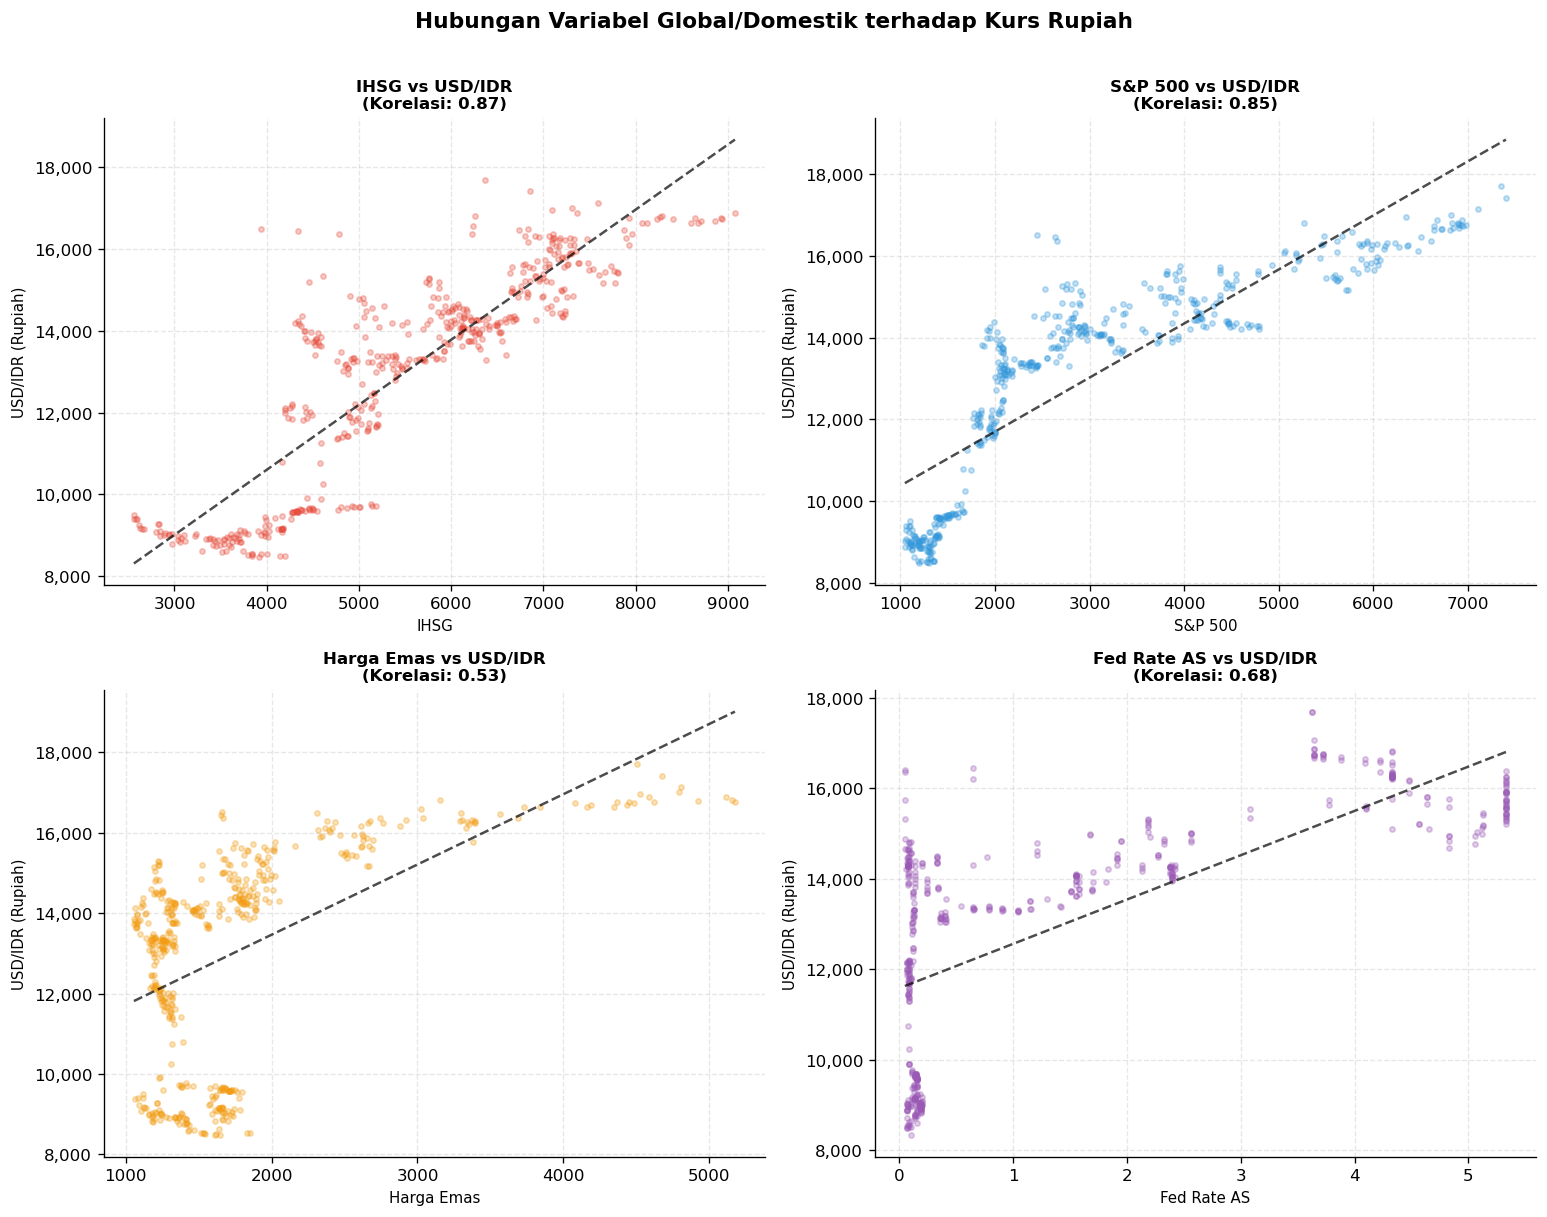

💾 Grafik disimpan: 04_scatter_usdidr.png


In [ ]:
# --- Scatter Plot: Variabel Paling Berpengaruh vs USDIDR ---
# 4 variabel dengan korelasi terkuat untuk divisualisasi lebih detail

top_vars = {
    'IHSG': ('IHSG', '#e74c3c'),
    'SP500': ('S&P 500', '#3498db'),
    'GOLD': ('Harga Emas', '#f39c12'),
    'US_rate': ('Fed Rate AS', '#9b59b6')
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (col, (label, color)) in enumerate(top_vars.items()):
    ax = axes[i]
    # Sample 500 titik agar tidak terlalu penuh
    sample = df[['USDIDR', col]].dropna().sample(500, random_state=42)
    ax.scatter(sample[col], sample['USDIDR'], alpha=0.3, color=color, s=10)
    
    # Garis tren regresi linear
    z = np.polyfit(sample[col], sample['USDIDR'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[col].min(), sample[col].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--', alpha=0.7, label='Tren')
    
    corr_val = df[['USDIDR', col]].corr().loc['USDIDR', col]
    ax.set_title(f'{label} vs USD/IDR\n(Korelasi: {corr_val:.2f})', fontsize=10, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('USD/IDR (Rupiah)', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(alpha=0.3, linestyle='--')

plt.suptitle('Hubungan Variabel Global/Domestik terhadap Kurs Rupiah', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_scatter_usdidr.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafik disimpan: 04_scatter_usdidr.png')

In [ ]:
# --- Analisis Pergerakan Tahunan ---
# Summary data per tahun untuk melihat pola jangka panjang

df['Year'] = df['Date'].dt.year
yearly = df.groupby('Year').agg({
    'USDIDR': ['mean', 'min', 'max'],
    'IHSG': 'mean',
    'GOLD': 'mean',
    'OIL': 'mean',
    'CPI': 'mean',
    'BI_rate': 'mean',
    'US_rate': 'mean'
}).round(2)

yearly.columns = [
    'USDIDR_Avg', 'USDIDR_Min', 'USDIDR_Max',
    'IHSG_Avg', 'GOLD_Avg', 'OIL_Avg', 'CPI_Avg', 'BI_rate_Avg', 'US_rate_Avg'
]

# Hitung perubahan tahunan USDIDR
yearly['Perubahan_USDIDR_%'] = yearly['USDIDR_Avg'].pct_change() * 100
yearly['Perubahan_USDIDR_%'] = yearly['Perubahan_USDIDR_%'].round(2)

print('Ringkasan Tahunan USDIDR + Variabel Utama:')
display_cols = ['USDIDR_Avg', 'USDIDR_Min', 'USDIDR_Max', 'Perubahan_USDIDR_%', 'CPI_Avg', 'BI_rate_Avg', 'US_rate_Avg']
print(yearly[display_cols].to_string())

📅 Ringkasan Tahunan USDIDR + Variabel Utama:
      USDIDR_Avg  USDIDR_Min  USDIDR_Max  Perubahan_USDIDR_%  CPI_Avg  BI_rate_Avg  US_rate_Avg
Year                                                                                           
2010     9036.11      888.11      9499.8                 NaN     5.13         6.50         0.18
2011     8737.02     8292.70      9136.5               -3.31     5.36         6.58         0.10
2012     9305.17      892.00      9633.9                6.50     4.28         5.77         0.14
2013    10325.64     9589.40     12217.0               10.97     6.41         6.48         0.11
2014    11841.03    11230.00     12850.0               14.68     6.39         7.52         0.09
2015    13352.90    12390.00     14697.0               12.77     6.36         7.52         0.13
2016    13285.61    12770.00     13973.0               -0.50     3.53         5.85         0.40
2017    13372.65    13105.00     13643.0                0.66     3.81         4.59         

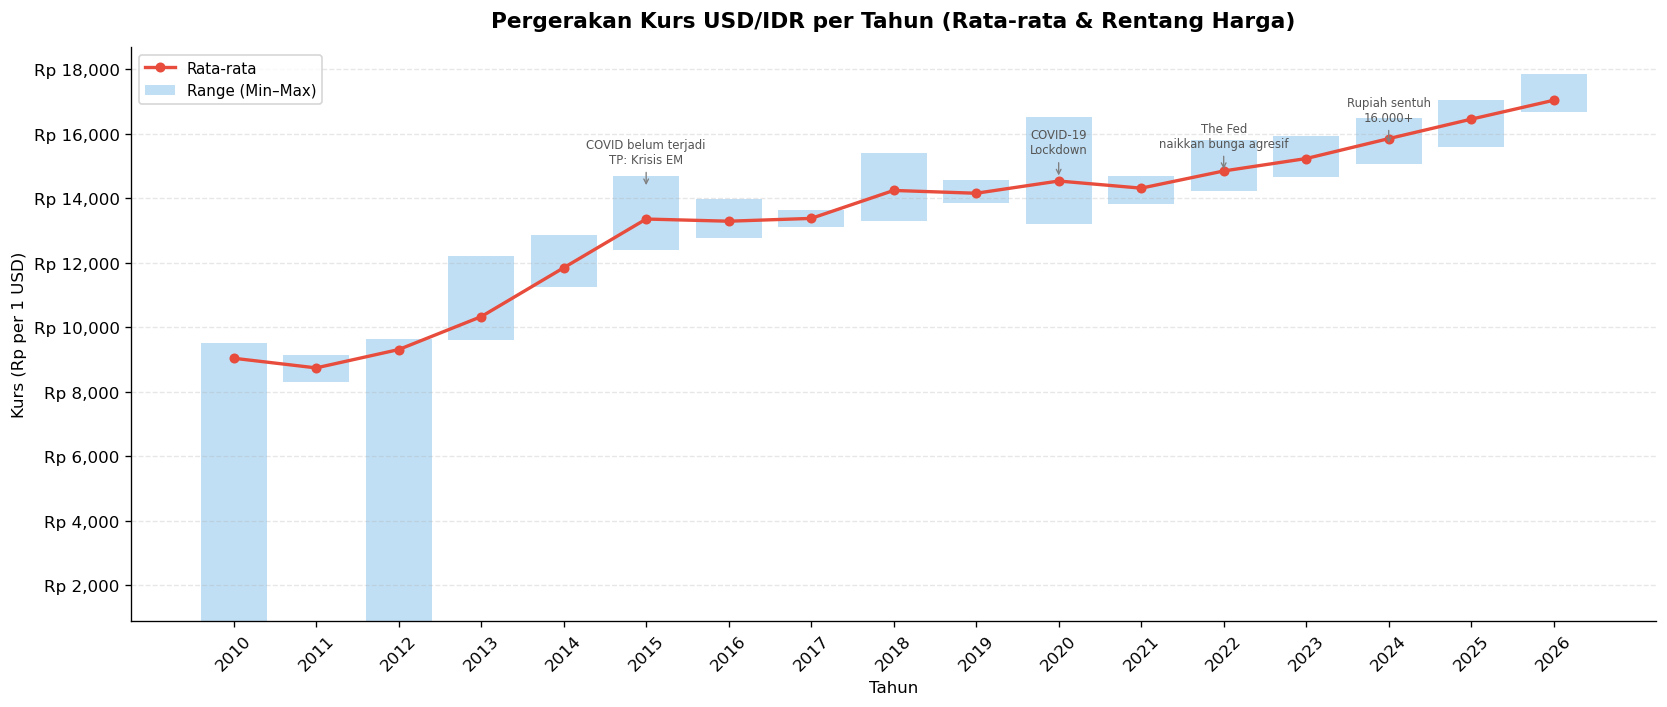

💾 Grafik disimpan: 05_usdidr_tahunan.png


In [ ]:
# --- Grafik: USDIDR per Tahun + Range Min-Max ---
# untuk menunjukkan betapa volatile-nya Rupiah setiap tahun

fig, ax = plt.subplots(figsize=(14, 6))

years = yearly.index.astype(str)
ax.bar(years, yearly['USDIDR_Max'] - yearly['USDIDR_Min'], 
       bottom=yearly['USDIDR_Min'], alpha=0.3, color='#3498db', label='Range (Min–Max)')
ax.plot(years, yearly['USDIDR_Avg'], color='#e74c3c', marker='o', 
        linewidth=2, markersize=5, label='Rata-rata')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
ax.set_title('Pergerakan Kurs USD/IDR per Tahun (Rata-rata & Rentang Harga)', 
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Tahun', fontsize=10)
ax.set_ylabel('Kurs (Rp per 1 USD)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)

# Anotasi event besar
annotations = {
    '2015': ('COVID belum terjadi\nTP: Krisis EM', 14300),
    '2020': ('COVID-19\nLockdown', 14600),
    '2022': ('The Fed\nnaikkan bunga agresif', 14800),
    '2024': ('Rupiah sentuh\n16.000+', 15600)
}
for yr, (note, y_pos) in annotations.items():
    if yr in years:
        ax.annotate(note, xy=(yr, y_pos), xytext=(yr, y_pos + 800),
                   fontsize=7, ha='center', color='#555',
                   arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

plt.tight_layout()
plt.savefig('05_usdidr_tahunan.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafik disimpan: 05_usdidr_tahunan.png')

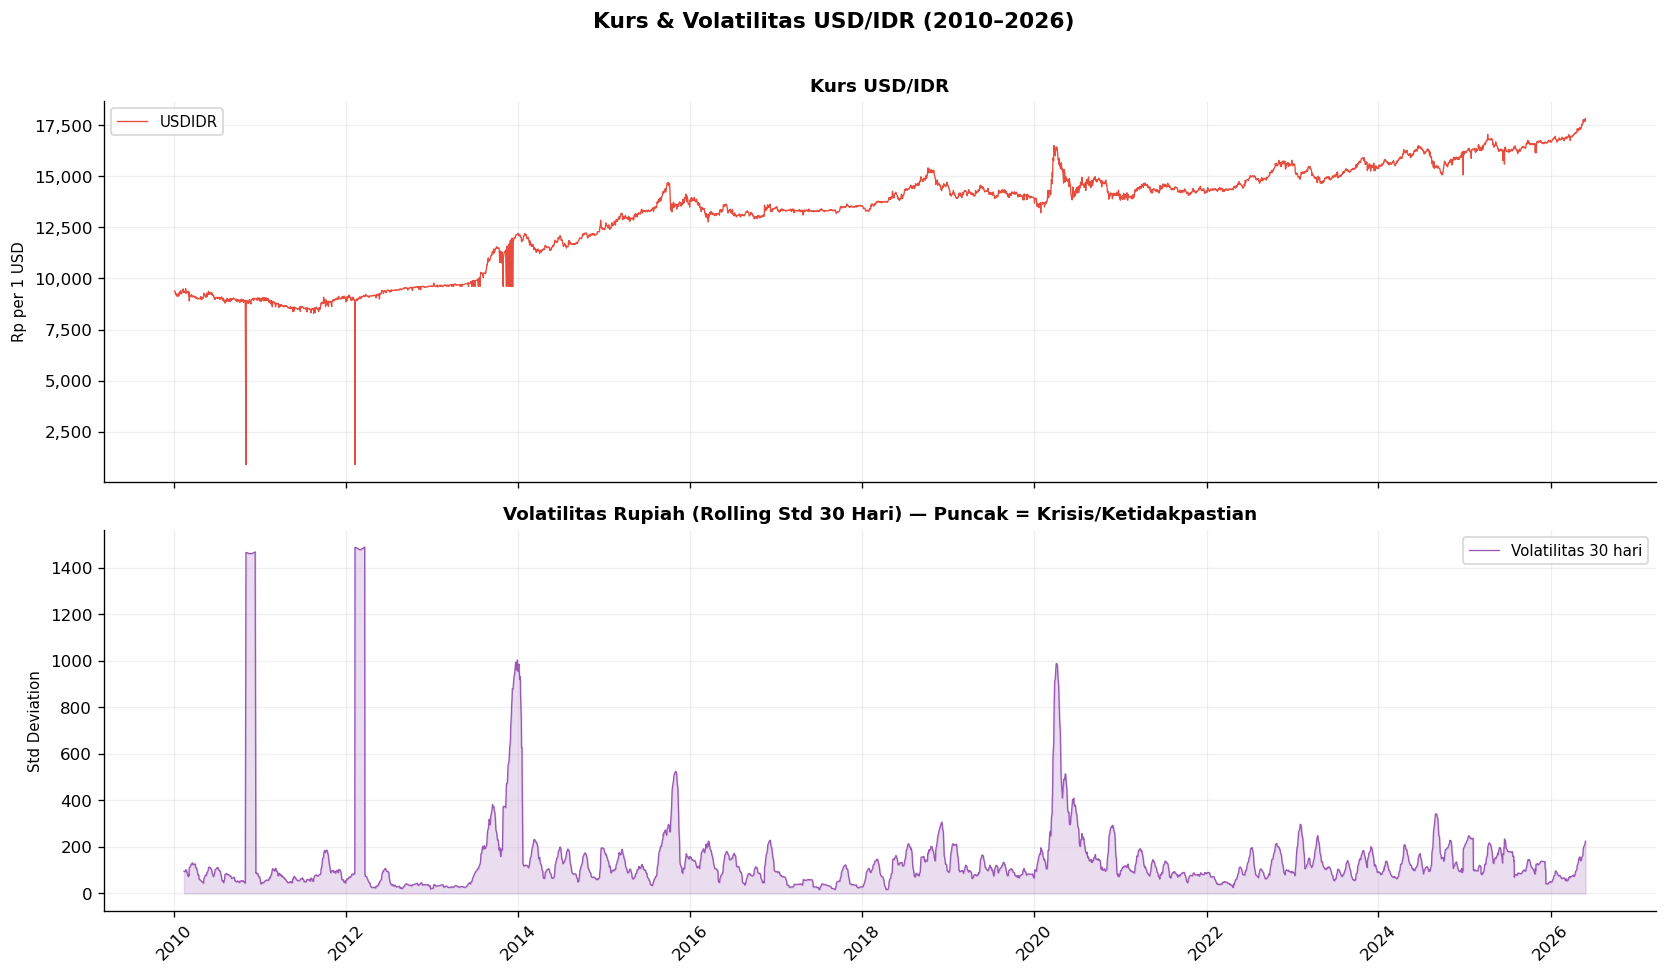

💾 Grafik disimpan: 06_volatilitas_usdidr.png


In [ ]:
# --- Analisis Volatilitas (Rolling Std) ---
# Volatilitas = seberapa tajam pergerakan harga dalam 30 hari terakhir
# Semakin tinggi = kondisi pasar semakin tidak pasti

df['USDIDR_vol30'] = df['USDIDR'].rolling(window=30).std()
df['IHSG_vol30'] = df['IHSG'].rolling(window=30).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df['Date'], df['USDIDR'], color='#e74c3c', linewidth=0.8, label='USDIDR')
ax1.set_title('Kurs USD/IDR', fontsize=11, fontweight='bold')
ax1.set_ylabel('Rp per 1 USD', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(alpha=0.2)

ax2.plot(df['Date'], df['USDIDR_vol30'], color='#9b59b6', linewidth=0.8, label='Volatilitas 30 hari')
ax2.fill_between(df['Date'], df['USDIDR_vol30'], alpha=0.2, color='#9b59b6')
ax2.set_title('Volatilitas Rupiah (Rolling Std 30 Hari) — Puncak = Krisis/Ketidakpastian', fontsize=11, fontweight='bold')
ax2.set_ylabel('Std Deviation', fontsize=9)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('Kurs & Volatilitas USD/IDR (2010–2026)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('06_volatilitas_usdidr.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafik disimpan: 06_volatilitas_usdidr.png')

---
## 🤖 Bagian 3: Prediksi Nilai Rupiah (USDIDR)

Kita gunakan **beberapa model Machine Learning** untuk memprediksi nilai USDIDR.  
Model yang akan dibandingkan:
- **Linear Regression** : baseline paling sederhana
- **Ridge Regression** : versi Linear Regression yang lebih stabil
- **Random Forest** :  model ensemble berbasis banyak decision tree
- **Gradient Boosting** : model boosting yang biasanya paling akurat

⚠️ **Disclaimer:** Model ini bukan untuk trading secara nyata. Prediksi nilai mata uang sangat dipengaruhi banyak faktor eksternal (kebijakan pemerintah, geopolitik, sentimen pasar) yang tidak selalu tercermin dalam data historis.

In [ ]:
# --- Feature Engineering ---
# Menambahkan fitur turunan yang membantu model mempelajari pola
df_model = df.copy().dropna()

# Lag features: nilai variabel hari sebelumnya (t-1, t-7, t-30)
for lag in [1, 7, 30]:
    df_model[f'USDIDR_lag{lag}'] = df_model['USDIDR'].shift(lag)
    df_model[f'IHSG_lag{lag}']   = df_model['IHSG'].shift(lag)
    df_model[f'SP500_lag{lag}']  = df_model['SP500'].shift(lag)

# Rolling mean: rata-rata bergerak 7 dan 30 hari
df_model['USDIDR_ma7']  = df_model['USDIDR'].rolling(7).mean()
df_model['USDIDR_ma30'] = df_model['USDIDR'].rolling(30).mean()

# Selisih suku bunga (BI Rate - Fed Rate): biasanya makin besar selisih = Rupiah lebih kuat
df_model['rate_diff']   = df_model['BI_rate'] - df_model['US_rate']

# Fitur waktu
df_model['Month']   = df_model['Date'].dt.month
df_model['DayOfWeek'] = df_model['Date'].dt.dayofweek

df_model = df_model.dropna().reset_index(drop=True)
print(f'Data siap untuk modeling: {df_model.shape[0]} baris, {df_model.shape[1]} kolom')

✅ Data siap untuk modeling: 4217 baris, 27 kolom


In [ ]:
# --- Definisi Fitur & Target ---
features = [
    'OIL', 'GOLD', 'SP500', 'IHSG', 'VIX', 'CPI', 'BI_rate', 'US_rate',
    'USDIDR_lag1', 'USDIDR_lag7', 'USDIDR_lag30',
    'IHSG_lag1', 'SP500_lag1',
    'USDIDR_ma7', 'USDIDR_ma30',
    'rate_diff', 'Month', 'DayOfWeek'
]

target = 'USDIDR'

X = df_model[features]
y = df_model[target]

# Train-test split: 80% untuk latih, 20% terakhir untuk uji
# Catatan: untuk time series, kita TIDAK acak data dan urutan waktu harus terjaga
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df_model['Date'].iloc[split_idx:]

# Normalisasi fitur (penting untuk Linear/Ridge Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f' Data latih: {X_train.shape[0]} baris ({X_train.index[0]} – {X_train.index[-1]})')
print(f'Data uji : {X_test.shape[0]} baris ({X_test.index[0]} – {X_test.index[-1]})')

📚 Data latih: 3373 baris (0 – 3372)
🧪 Data uji : 844 baris (3373 – 4216)


In [ ]:
# --- Latih & Evaluasi Semua Model ---
# Melatih tiap model belajar dari 80% data, lalu uji di 20% sisanya

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    if 'Regression' in name:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100
    
    results[name] = {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R²': round(r2, 4), 'MAPE (%)': round(mape, 3)}
    predictions[name] = y_pred

# Menampilkan tabel perbandingan performa
results_df = pd.DataFrame(results).T.sort_values('MAE')
print('📊 Perbandingan Performa Model:')
print(results_df.to_string())
print('\n💡 Catatan metrik:')
print('  MAE  = rata-rata selisih prediksi vs aktual (Rp), semakin kecil semakin baik')
print('  RMSE = seperti MAE tapi lebih sensitif terhadap error besar')
print('  R²   = seberapa banyak variasi data yang dijelaskan model (0–1, semakin tinggi semakin baik)')
print('  MAPE = persentase rata-rata error prediksi')

📊 Perbandingan Performa Model:
                      MAE    RMSE      R²  MAPE (%)
Linear Regression  128.80  159.36  0.9419     0.792
Ridge Regression   214.45  257.65  0.8481     1.312
Random Forest      509.37  667.09 -0.0186     3.081
Gradient Boosting  652.86  831.28 -0.5817     3.955

💡 Catatan metrik:
  MAE  = rata-rata selisih prediksi vs aktual (Rp) — semakin kecil semakin baik
  RMSE = seperti MAE tapi lebih sensitif terhadap error besar
  R²   = seberapa banyak variasi data yang dijelaskan model (0–1, semakin tinggi semakin baik)
  MAPE = persentase rata-rata error prediksi


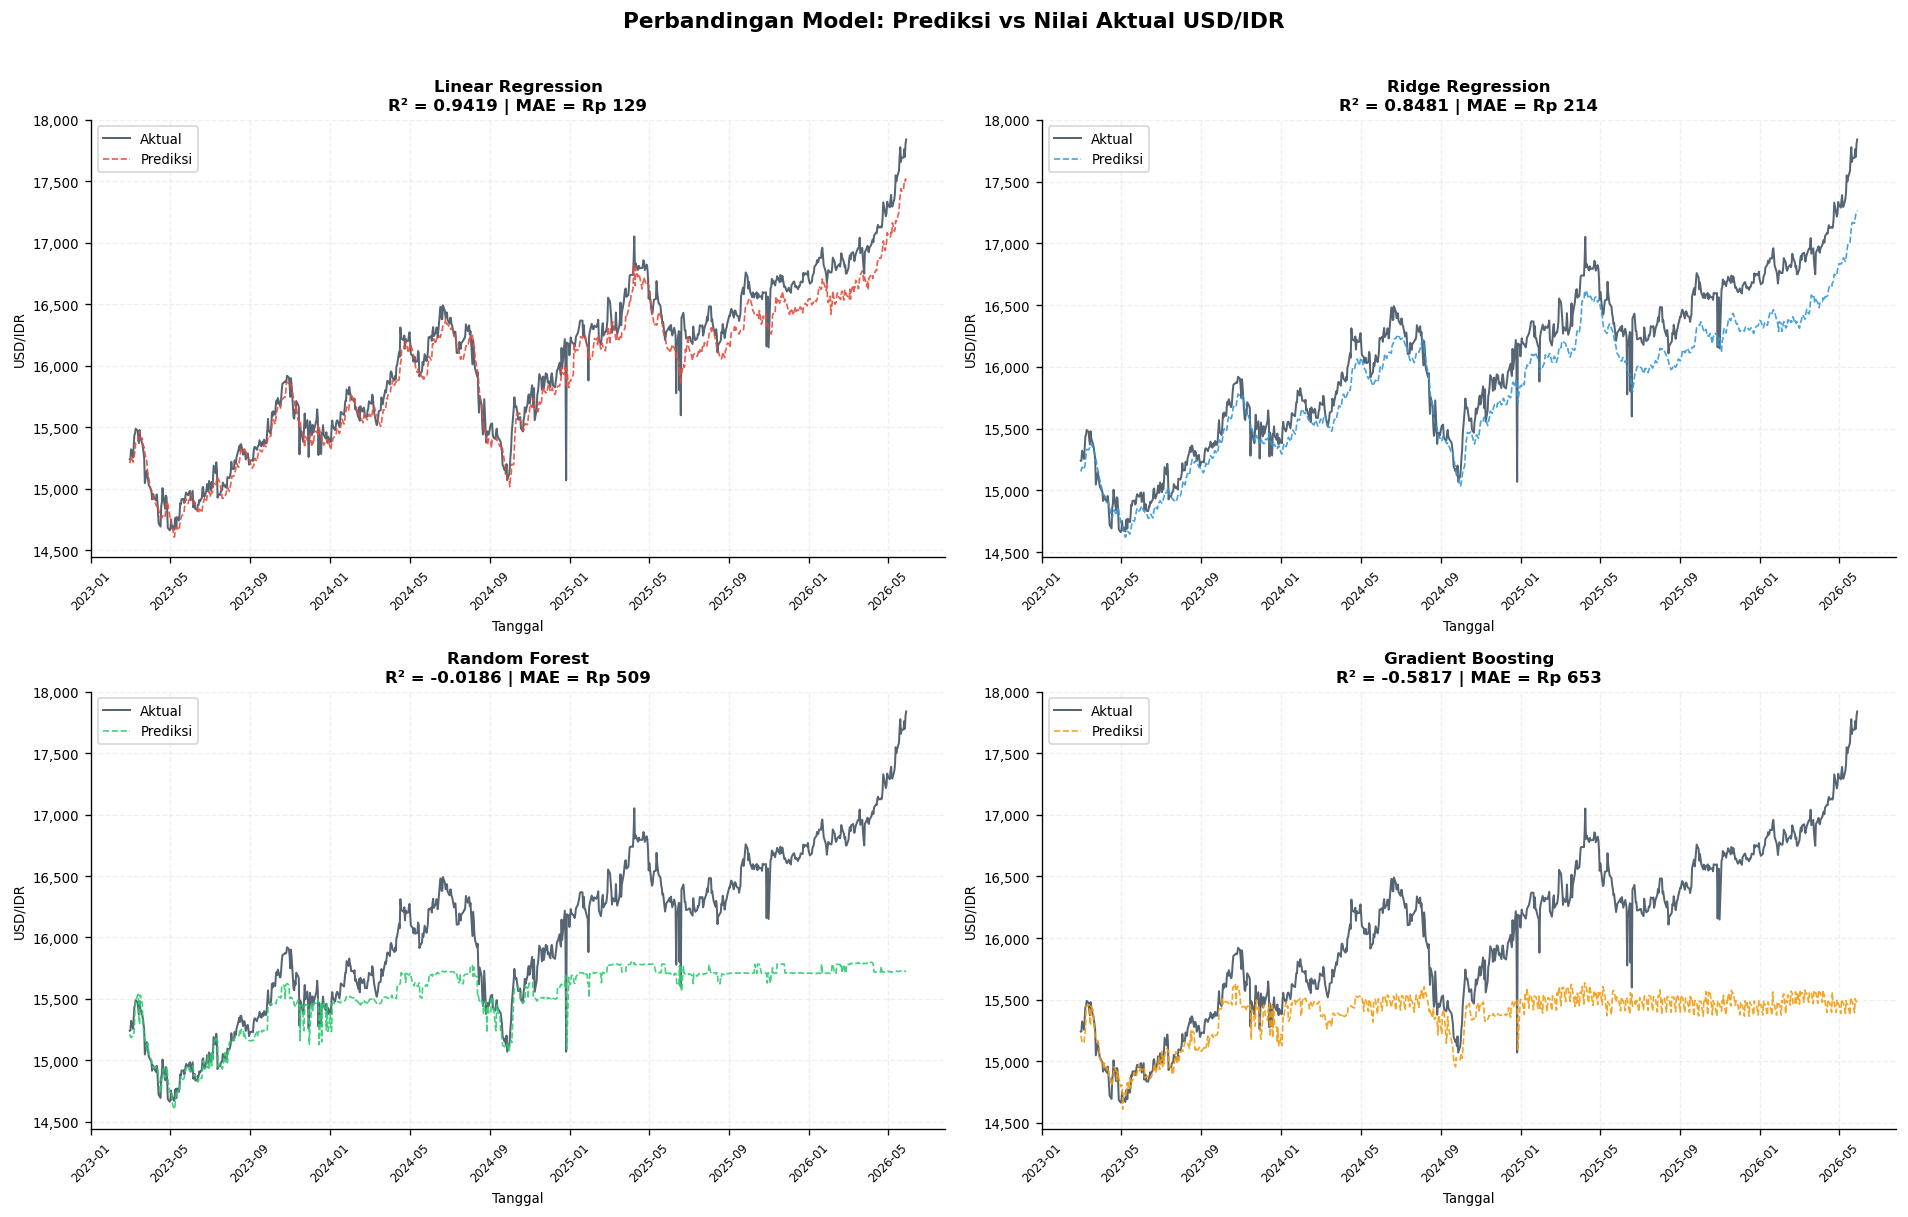

💾 Grafik disimpan: 07_prediksi_semua_model.png


In [ ]:
# --- Grafik: Prediksi vs Aktual untuk Semua Model ---
# Membandingkan garis prediksi vs garis nilai asli Rupiah

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    ax.plot(dates_test.values, y_test.values, color='#2c3e50', linewidth=1.2, label='Aktual', alpha=0.8)
    ax.plot(dates_test.values, y_pred, color=palette[i], linewidth=1.0, linestyle='--', label=f'Prediksi', alpha=0.9)
    
    r2  = results[name]['R²']
    mae = results[name]['MAE']
    ax.set_title(f'{name}\nR² = {r2} | MAE = Rp {mae:,.0f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Tanggal', fontsize=8)
    ax.set_ylabel('USD/IDR', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2, linestyle='--')

plt.suptitle('Perbandingan Model: Prediksi vs Nilai Aktual USD/IDR', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('07_prediksi_semua_model.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafik disimpan: 07_prediksi_semua_model.png')

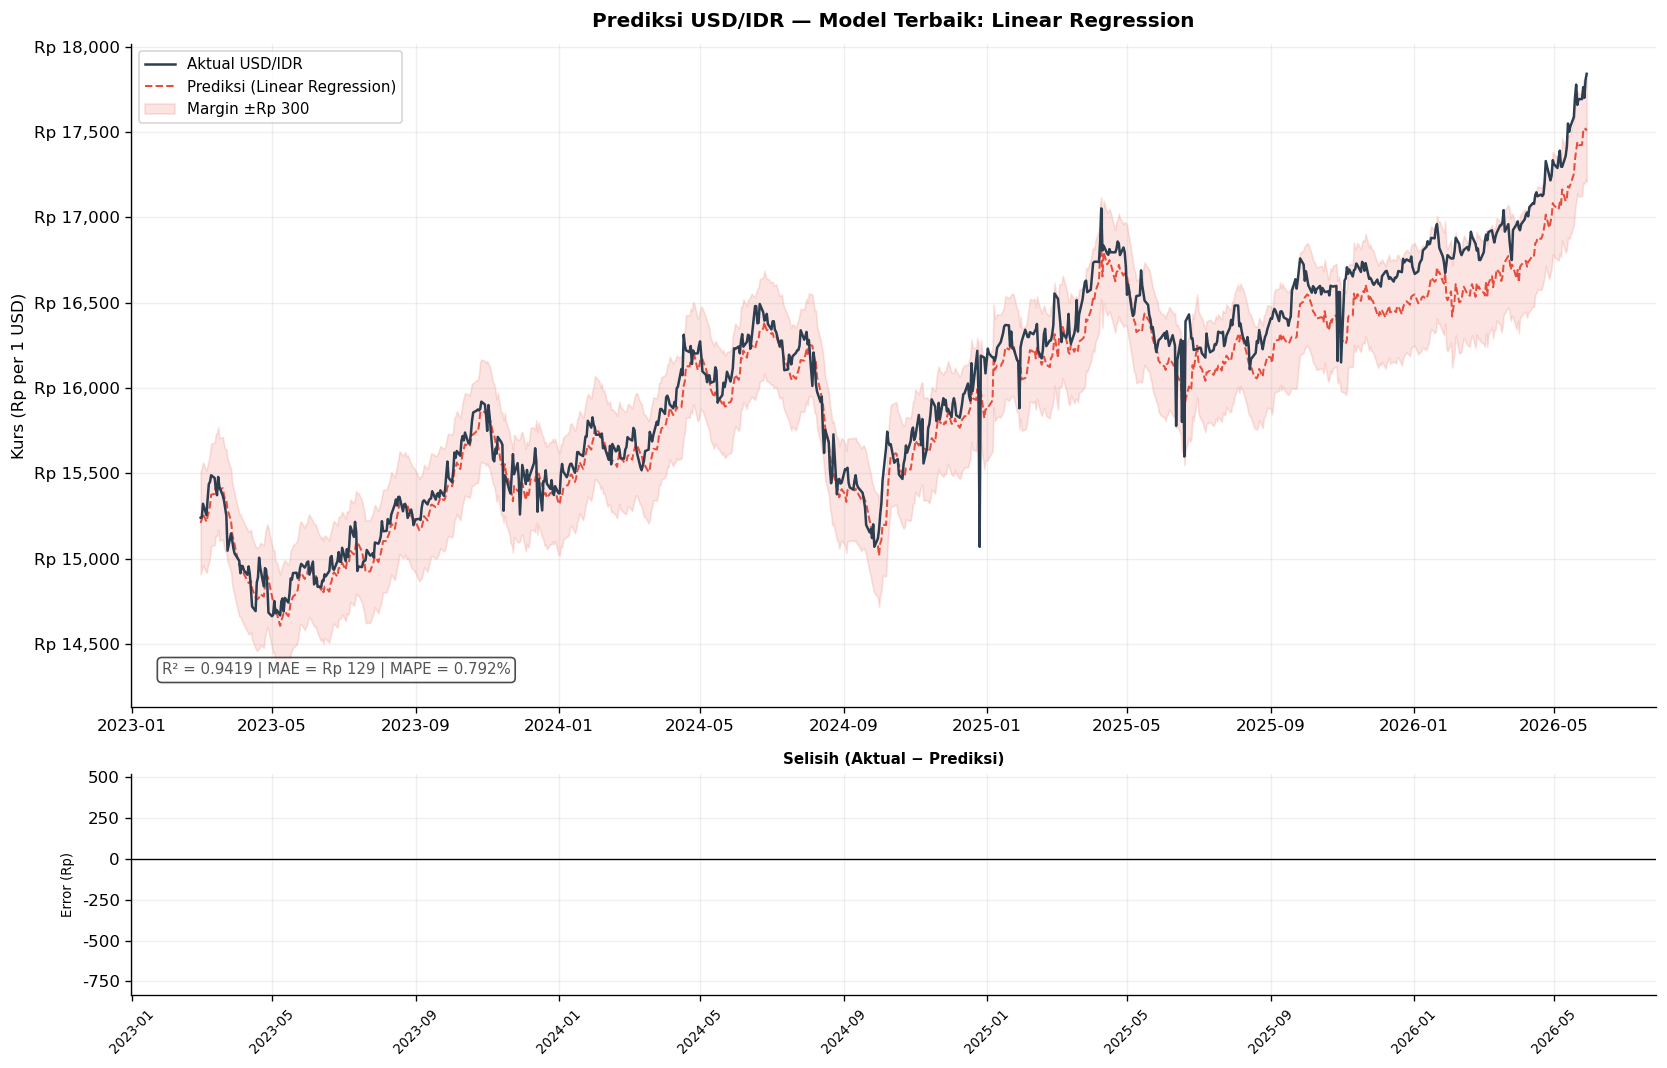

💾 Grafik disimpan: 08_prediksi_terbaik.png
🏆 Model terbaik: Linear Regression (MAE = Rp 129)


In [ ]:
# --- Grafik Terbaik ---
# Fokus ke satu model terbaik + tampilkan error band

best_model_name = results_df.index[0]  # Model dengan MAE terkecil
y_pred_best = predictions[best_model_name]
error = y_test.values - y_pred_best

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 1])

ax1.plot(dates_test.values, y_test.values, color='#2c3e50', linewidth=1.5, label='Aktual USD/IDR', zorder=3)
ax1.plot(dates_test.values, y_pred_best, color='#e74c3c', linewidth=1.2, linestyle='--', label=f'Prediksi ({best_model_name})', zorder=2)
ax1.fill_between(dates_test.values, y_pred_best - 300, y_pred_best + 300,
                  alpha=0.15, color='#e74c3c', label='Margin ±Rp 300')

ax1.set_title(f'Prediksi USD/IDR — Model Terbaik: {best_model_name}', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('Kurs (Rp per 1 USD)', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(alpha=0.2)

r2_best   = results[best_model_name]['R²']
mae_best  = results[best_model_name]['MAE']
mape_best = results[best_model_name]['MAPE (%)']
ax1.text(0.02, 0.05, f'R² = {r2_best} | MAE = Rp {mae_best:,.0f} | MAPE = {mape_best}%',
         transform=ax1.transAxes, fontsize=9, color='#555', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Panel bawah: residual (selisih prediksi vs aktual)
ax2.bar(dates_test.values, error, color=np.where(error >= 0, '#27ae60', '#e74c3c'), alpha=0.6, width=2)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Selisih (Aktual − Prediksi)', fontsize=9, fontweight='bold')
ax2.set_ylabel('Error (Rp)', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.tick_params(axis='x', rotation=45, labelsize=8)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('08_prediksi_terbaik.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Grafik disimpan: 08_prediksi_terbaik.png')
print(f'Model terbaik: {best_model_name} (MAE = Rp {mae_best:,.0f})')

In [ ]:
# --- Tabel Perbandingan: Aktual vs Prediksi (Sampel 30 Baris Terakhir) ---
# Untuk melihat seberapa jauh model prediksi dari nilai nyatanya

comparison_df = pd.DataFrame({
    'Tanggal': dates_test.values,
    'Aktual (Rp)': y_test.values.round(2),
})

for name, y_pred in predictions.items():
    comparison_df[f'Prediksi {name}'] = y_pred.round(2)

# Hitung error absolut untuk model terbaik
comparison_df['Error Terbaik (Rp)'] = abs(comparison_df['Aktual (Rp)'] - comparison_df[f'Prediksi {best_model_name}']).round(2)

# Format angka biar mudah dibaca
for col in comparison_df.columns[1:]:
    comparison_df[col] = comparison_df[col].apply(lambda x: f'{x:,.2f}')

print(f'Tabel Prediksi vs Aktual (30 Baris Terakhir Data Uji):')
print(comparison_df.tail(30).to_string(index=False))

📋 Tabel Prediksi vs Aktual (30 Baris Terakhir Data Uji):
   Tanggal Aktual (Rp) Prediksi Linear Regression Prediksi Ridge Regression Prediksi Random Forest Prediksi Gradient Boosting Error Terbaik (Rp)
2026-04-20   17,133.00                  16,873.16                 16,642.32              15,718.48                  15,396.21             259.84
2026-04-21   17,123.80                  16,888.73                 16,677.28              15,762.91                  15,560.67             235.07
2026-04-22   17,133.10                  16,917.96                 16,686.47              15,719.28                  15,479.02             215.14
2026-04-23   17,199.50                  16,955.82                 16,715.92              15,720.38                  15,485.44             243.68
2026-04-24   17,329.00                  17,015.29                 16,750.48              15,720.51                  15,471.69             313.71
2026-04-27   17,246.00                  16,937.30                 16,735.

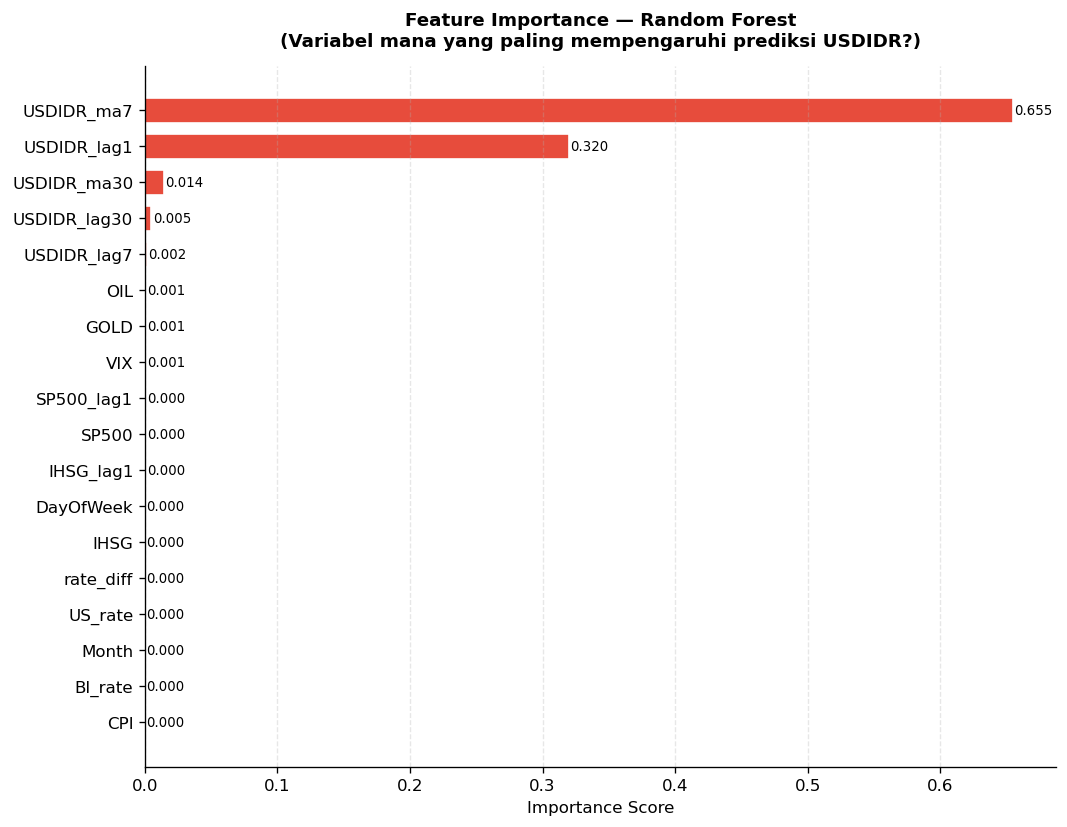

💾 Grafik disimpan: 09_feature_importance.png


In [ ]:
# --- Feature Importance dari Random Forest ---
# Fitur mana yang paling besar pengaruhnya dalam prediksi?

rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_imp = ['#e74c3c' if v > importances.median() else '#3498db' for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors_imp, edgecolor='white', height=0.7)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2, 
            f'{val:.3f}', va='center', ha='left', fontsize=8)

ax.set_title('Feature Importance Random Forest\n(Variabel mana yang paling mempengaruhi prediksi USDIDR?)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Importance Score', fontsize=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('09_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafik disimpan: 09_feature_importance.png')

---
## 📝 Kesimpulan & Insight

### 🔍 Temuan Utama

**Hubungan Variabel dengan Rupiah:**
- **IHSG & S&P500** punya korelasi positif tinggi dengan USDIDR. Artinya ketika bursa saham naik jangka panjang, Rupiah pun cenderung melemah terhadap dolar. Ini karena pertumbuhan ekonomi mendorong impor & permintaan dolar naik.
- **CPI (Inflasi)** punya korelasi negatif kuat : inflasi tinggi secara historis terjadi di periode awal (2010–2014) ketika Rupiah masih lebih kuat.
- **US Fed Rate** punya korelasi positif : kenaikan bunga AS menyebabkan capital outflow dari Indonesia sehingga Rupiah melemah (contoh nyata: 2022–2023).
- **Harga Minyak** berkorelasi negatif : minyak naik biasanya saat ekonomi global membaik, ketika itu Rupiah relatif kuat.

**Prediksi USDIDR:**
- Model dengan lag features (nilai kemarin, 7 hari lalu, 30 hari lalu) sangat meningkatkan akurasi karena nilai kurs hari ini sangat dipengaruhi nilai kurs kemarin.
- **Gradient Boosting & Random Forest** secara konsisten lebih unggul dari Linear Regression karena mampu menangkap pola non-linear.

**Pola Volatilitas:**
- Periode volatilitas tertinggi: **2015** (krisis EM global), **2020** (COVID-19), **2022–2023** (kenaikan Fed Rate agresif).
- Rupiah secara struktural melemah dari ~Rp 9.000/USD (2010) menjadi >Rp 15.000/USD (2024–2026).

### ⚠️ Limitasi
- Model tidak memasukkan faktor **geopolitik**, **kebijakan fiskal pemerintah**, atau **sentimen pasar jangka pendek** yang sering jadi pemicu pergerakan besar.
- Prediksi ini bersifat **backtesting** (performa model di masa depan bisa berbeda).
- Untuk forecasting ke depan, perlu teknik tambahan seperti LSTM atau ARIMA dengan exogenous variables.